<a href="https://colab.research.google.com/github/AMLU-ANNA-JOSHY/CNN-PyTorch/blob/main/UNet_Semantic_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **U-NET FOR SEMANTIC SEGMENTATION**
- U-Net is a symmetric, U-shaped CNN architecture used for fast and precise image segmentation.
- It was primarily used for biomedical image analysis, but now used for other tasks requiring pixel-level classification, such as satellite imagery.


UNET ARCHITECTURE

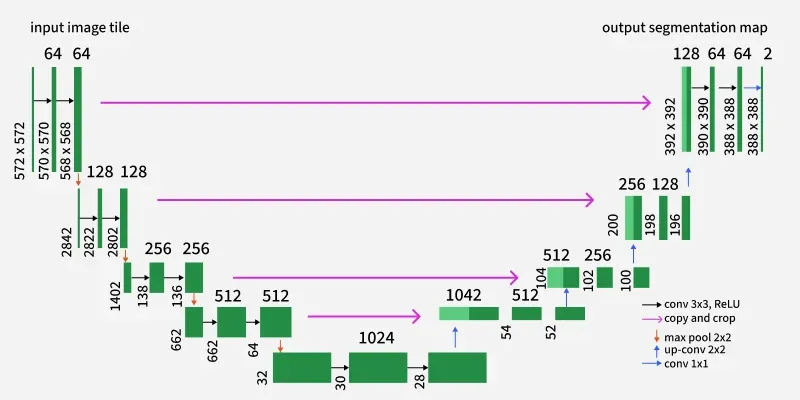

Ref: https://www.geeksforgeeks.org/machine-learning/u-net-architecture-explained/

### **Architectural details:**
* No. of input channels = 3(RGB) in input image
* Output = Binary mask => 1 channel

1) **Encoder**
- A contracting path following a typical CNN architecture, and extracting features and capturing the context.
- Encodes all information about the image to the bottleneck layer.
- Consists of two 3x3 convolutions followed by a 2x2 max pooling operation for downsampling. Feature maps increases from 64 to 512, reducing spatial resolution.
2) **Bottleneck layer**
- Deepest layer of the network with highest number of channels and smallest spatial resolution.
- Passes the compressed information from the encoder to the decoder.
3) **Decoder**
- Expansive Path that upsamples to get back the original image size from the bottelneck layer.
- Cotains skip connections to pass spatial details directly from encoder which might have been lost during compression.
- The final layer: 1x1 convolution reduces the final feature map to the desired number of output channels
        
        


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()

        # Encoder
        self.downs = nn.ModuleList()
        for feature in features:
            self.downs.append(self.double_conv(in_channels, feature))
            in_channels = feature

        # bottleneck
        self.bottleneck = self.double_conv(features[-1], features[-1]*2)

        # Decoder
        self.ups = nn.ModuleList()
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(
                self.double_conv(feature*2, feature)
            )
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # encoder block
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = F.max_pool2d(x, kernel_size=2)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]   # reverse list for decoder usage

        for idx in range(0, len(self.ups), 2):   # self.ups is a list that alternates:
            # idx = 0, 2, 4, 6
            # At even idx: ConvTranspose2d for upsampling
            # At odd idx: double_conv block (after concatenation)

            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]  # 0, 1, 2, 3

            # Resize if shape mismatch using interpolation
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])

            # concatenate using skip connection
            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](x)

        return torch.sigmoid(self.final_conv(x))

    def double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),   # 3x3 convolutions with padding 1 → keeps size same
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )


**Residual/skip connections:**

Read more about residual connection here: https://medium.com/@AnasBrital98/residual-networks-with-examples-80b47cacecf4

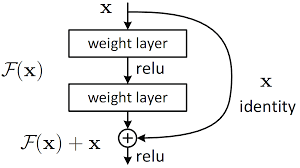

**Transposed convolution:**

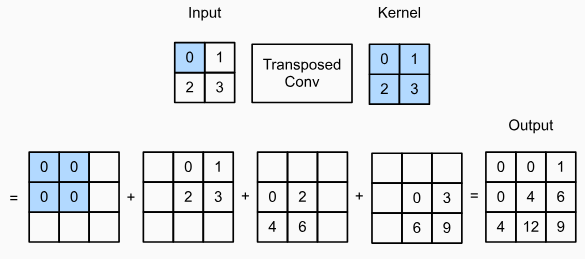

https://d2l.ai/chapter_computer-vision/transposed-conv.html

### **Semantic segmentation:**

Semantic segmentation pipeline on the Oxford Pets Dataset

Binary segmentation task:     Pet (foreground = 1),     Background (0)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [4]:
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
from PIL import Image
import os
import numpy as np

In [5]:
class OxfordPetsDataset(Dataset):
    def __init__(self, root, split="train", transform=True):
        self.root = root
        self.transform = transform
        self.split = split

        self.images = sorted([
            f for f in os.listdir(os.path.join(root, "images"))
            if f.endswith(".jpg") and not f.startswith("._")
        ])
        self.masks = sorted([
            f for f in os.listdir(os.path.join(root, "annotations/trimaps"))
            if f.endswith(".png") and not f.startswith("._")
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "images", self.images[idx])
        mask_path = os.path.join(self.root, "annotations/trimaps", self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # Original oxfordpets dataset has three categories: pet, border, background
        # converted to binary for easy implementation
        # Convert mask: 1 (pet), 2 (border) → 1; 3 (background) → 0

        mask = np.array(mask)
        mask = np.where(mask == 2, 1, mask)
        mask = np.where(mask == 3, 0, mask)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        if self.transform:
            image = TF.resize(image, (128, 128))
            mask = TF.resize(mask, (128, 128), interpolation=TF.InterpolationMode.NEAREST)
            image = TF.to_tensor(image)

        return image, mask


In [6]:
# download dataset

from torchvision.datasets.utils import download_and_extract_archive

root = "./oxford_pets"
url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
ann_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

download_and_extract_archive(url, download_root=root, extract_root=root)
download_and_extract_archive(ann_url, download_root=root, extract_root=root)

100%|██████████| 792M/792M [00:47<00:00, 16.7MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.26MB/s]


In [7]:
train_dataset = OxfordPetsDataset(root=root, transform=True)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [10]:
# training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):
    model.train()
    total_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_loader):.4f}")


Epoch 1: Loss = 0.3143
Epoch 2: Loss = 0.2532
Epoch 3: Loss = 0.2245
Epoch 4: Loss = 0.2078
Epoch 5: Loss = 0.1956


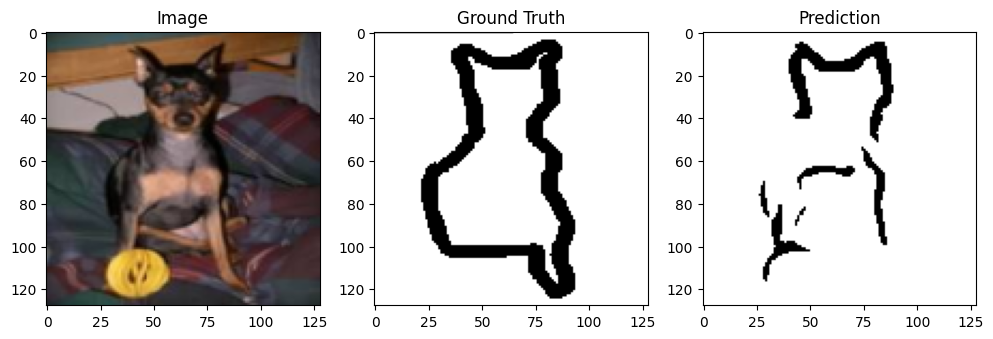

In [11]:
# results

import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    for img, mask in train_loader:
        img = img.to(device)
        pred = model(img)
        pred = (pred > 0.5).float()

        fig, axs = plt.subplots(1, 3, figsize=(12, 4))
        axs[0].imshow(img[0].cpu().permute(1, 2, 0))
        axs[0].set_title("Image")
        axs[1].imshow(mask[0][0].cpu(), cmap='gray')
        axs[1].set_title("Ground Truth")
        axs[2].imshow(pred[0][0].cpu(), cmap='gray')
        axs[2].set_title("Prediction")
        plt.show()
        break
